In [9]:
from src.mesh import Mesh3D
import numpy as np
from skimage.measure import marching_cubes
import pyvista as pv
from scipy.interpolate import griddata
import matplotlib.pyplot as plt
from scipy.signal import find_peaks

In [2]:
euler_cube = np.load('./output/euler_cube.npy')
coord_cube = np.load('./output/coord_cube.npy')
Nb_cube = np.load('./output/Nb_cube.npy')
Sn_cube = np.load('./output/Sn_cube.npy')
points = np.load('./output/points.npy')
euler_flat = np.load('./output/euler_flat.npy')
Sn_flat = np.load('./output/Sn_flat.npy')
Sn_points = np.copy(points)
phase_flat = np.load('./output/phase_flat.npy')

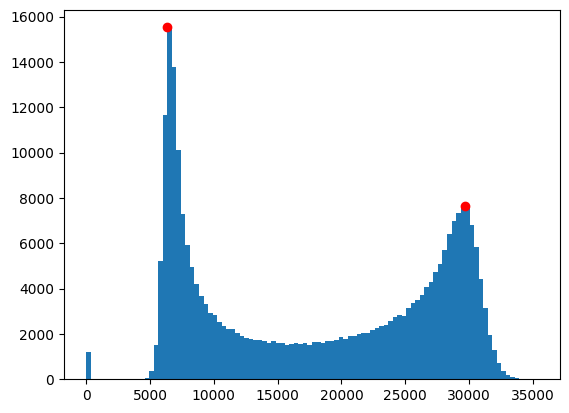

In [10]:


counts, bin_edges, patches = plt.hist(Sn_flat, bins=100)
peaks, _ = find_peaks(counts, height=6000)
plt.scatter(bin_edges[peaks], counts[peaks], c="red")
lower_Sn_peak, upper_Sn_peak = bin_edges[peaks]

In [3]:
"""Find the vacuum interface"""


total_xray_cube = Nb_cube + Sn_cube
total_xray_cube = np.pad(total_xray_cube, pad_width=10, mode='edge')
Nb_cube = np.pad(Nb_cube, pad_width=10, mode='edge')

verts, faces, normals, values = marching_cubes(total_xray_cube,120000,spacing=(0.1,0.1,0.1))
verts = verts - np.array((1.0,1.0,1.0))
surface_mesh = pv.PolyData.from_regular_faces(verts, faces).subdivide(1).smooth(n_iter=10, relaxation_factor=0.1, boundary_smoothing=False).compute_normals(auto_orient_normals=True).triangulate()

verts, faces, normals, values = marching_cubes(Nb_cube,165000,spacing=(0.1,0.1,0.1))
verts = verts - np.array((1.0,1.0,1.0))
substrate_mesh = pv.PolyData.from_regular_faces(verts, faces).smooth(n_iter=20, relaxation_factor=0.1, boundary_smoothing=False).compute_normals(auto_orient_normals=True).triangulate()

"""Find points in vacuum"""
points_pv = pv.PolyData(points)
outside_points = points_pv.select_enclosed_points(surface_mesh.extrude([-10.0,0.0,0.0], capping=True), inside_out=True)
outside_mask = outside_points['SelectedPoints'].view(np.bool_)

phase_flat[outside_mask] = 3    # 3 -> Vacuum

point_data = {
    "euler": euler_flat,
    "phase": phase_flat
}

bounds = np.array(((0.0, 0.1*coord_cube.shape[0]),
        (0.0, 0.1*coord_cube.shape[1]),
        (0.0, 0.1*coord_cube.shape[2])))

mesh = Mesh3D(points, point_data, bounds)

/home/vike/dev/3debsd/.venv/lib/python3.13/site-packages/scipy/sparse/_index.py:210: SparseEfficiencyWarning: Changing the sparsity structure of a csr_array is expensive. lil and dok are more efficient.
  self._set_arrayXarray(i, j, x)


In [17]:
from matplotlib.colors import ListedColormap


pv.set_jupyter_backend('client')
pv.global_theme.allow_empty_mesh = True

plotter = pv.Plotter(off_screen=True, window_size=(1920, 1080))
# Set the number of frames
n_frames = 10

grains = mesh.grains
grain_phase = mesh.grain_phase

colors = np.random.rand(len(grains),3)
plane_color = pv.Color(opacity=0.5)

bbox = bounds

points = Sn_points
# scalars = Sn_flat
scalars = phase_flat
discrete_cmap = ListedColormap(["#FF0000", "#00FF00", "#0000FF", "#FFFF00",])
x_slices = np.concatenate((np.linspace(4.0, 0.1, n_frames//2, endpoint=False), np.linspace(0.1, 4.0, n_frames - n_frames//2)))

rotation_angle = 720
camera_angles = np.linspace(0, rotation_angle, num=n_frames)

# Open a movie file (this starts recording frames)
plotter.open_movie("rotating_movie.mp4", framerate = 24)



# Loop to rotate and record frames
for i in range(n_frames):
    print(f"Starting frame {i}")

    plotter.clear()




    plane_x = x_slices[i]
    grid_y, grid_z = np.meshgrid(np.linspace(bbox[1][0]-0.1, bbox[1][1]+0.1, 100), np.linspace(bbox[2][0]-0.1, bbox[2][1]+0.1, 100))
    grid_x = np.full_like(grid_y, plane_x)
    grid_points = np.c_[grid_x.ravel(), grid_y.ravel(), grid_z.ravel()]


    # Find the indices of points where the z-coordinate is within the range
    indices = np.where((points[:, 0] >= plane_x - 0.5) & (points[:, 0] <= plane_x + 0.5))

    interpolated_scalars = griddata(points[indices], scalars[indices], grid_points, method='nearest')

    structured_grid = pv.StructuredGrid()
    structured_grid.points = np.c_[grid_x.ravel(), grid_y.ravel(), grid_z.ravel()]
    structured_grid.dimensions = grid_x.shape + (1,)
    structured_grid["interpolated_scalar"] = interpolated_scalars

    # plotter.add_mesh(structured_grid.rotate_y(-90).rotate_z(180).translate([0.1,0.1+bounds[1][1],0.1]), scalars="interpolated_scalar", cmap="viridis", clim=[lower_Sn_peak, upper_Sn_peak], show_edges=False, opacity=0.8)
    plotter.add_mesh(structured_grid.rotate_y(-90).rotate_z(180).translate([0.1,0.1+bounds[1][1],0.1]), scalars="interpolated_scalar", cmap=discrete_cmap, show_edges=False, opacity=0.8)

    for id in range(len(grains)):

        if (grain_phase[id] == 3).any():
            continue

        if len(grains[id]) > 10:
            grain_mesh = mesh.plot_grain(id)
            plotter.add_mesh(grain_mesh.intersection(structured_grid.extract_surface().triangulate(), split_first=False, split_second=False)[0].rotate_y(-90).rotate_z(180).translate([0.1,0.1+bounds[1][1],0.1]), line_width=4)
            plotter.add_mesh(grain_mesh.clip_surface(structured_grid).rotate_y(-90).rotate_z(180).translate([0.1,0.1+bounds[1][1],0.1]), color=colors[id])
            plotter.add_mesh(grain_mesh.clip_surface(structured_grid, invert=False).rotate_y(-90).rotate_z(180).translate([0.1,0.1+bounds[1][1],0.1]), color=colors[id],opacity=0.05)


    plotter.camera.azimuth = camera_angles[i]
    plotter.render()
    plotter.write_frame()

plotter.close()


Starting frame 0
Filtered out 0 faces with out-of-bounds vertices
Filtered out 0 faces with out-of-bounds vertices


2025-11-07 11:30:10.881 (154019.565s) [    79A39CBFF100]vtkIntersectionPolyData:2423  WARN|No Intersection between objects 
2025-11-07 11:30:10.999 (154019.683s) [    79A39CBFF100]vtkIntersectionPolyData:2423  WARN|No Intersection between objects 


Filtered out 0 faces with out-of-bounds vertices
Filtered out 0 faces with out-of-bounds vertices


2025-11-07 11:30:11.084 (154019.768s) [    79A39CBFF100]vtkIntersectionPolyData:2423  WARN|No Intersection between objects 
2025-11-07 11:30:11.230 (154019.913s) [    79A39CBFF100]vtkIntersectionPolyData:2423  WARN|No Intersection between objects 


Filtered out 0 faces with out-of-bounds vertices
Filtered out 0 faces with out-of-bounds vertices


...

2025-11-07 11:31:13.651 (154082.335s) [    79A39CBFF100]vtkIntersectionPolyData:2423  WARN|No Intersection between objects 
2025-11-07 11:31:13.708 (154082.391s) [    79A39CBFF100]vtkIntersectionPolyData:2423  WARN|No Intersection between objects 
2025-11-07 11:31:13.760 (154082.443s) [    79A39CBFF100]vtkIntersectionPolyData:2423  WARN|No Intersection between objects 
2025-11-07 11:31:13.814 (154082.497s) [    79A39CBFF100]vtkIntersectionPolyData:2423  WARN|No Intersection between objects 


Filtered out 0 faces with out-of-bounds vertices
Filtered out 0 faces with out-of-bounds vertices
Filtered out 0 faces with out-of-bounds vertices
Filtered out 0 faces with out-of-bounds vertices


2025-11-07 11:31:13.857 (154082.541s) [    79A39CBFF100]vtkIntersectionPolyData:2423  WARN|No Intersection between objects 
2025-11-07 11:31:13.909 (154082.593s) [    79A39CBFF100]vtkIntersectionPolyData:2423  WARN|No Intersection between objects 
2025-11-07 11:31:13.959 (154082.642s) [    79A39CBFF100]vtkIntersectionPolyData:2423  WARN|No Intersection between objects 
2025-11-07 11:31:14.010 (154082.693s) [    79A39CBFF100]vtkIntersectionPolyData:2423  WARN|No Intersection between objects 


Filtered out 0 faces with out-of-bounds vertices
Filtered out 0 faces with out-of-bounds vertices


2025-11-07 11:31:14.062 (154082.746s) [    79A39CBFF100]vtkIntersectionPolyData:2423  WARN|No Intersection between objects 
2025-11-07 11:31:14.112 (154082.796s) [    79A39CBFF100]vtkIntersectionPolyData:2423  WARN|No Intersection between objects 
